# CNN으로 MNIST 손글씨 구분하기
Convolutional Neural Network (CNN) 을 이용하여 MNIST 숫자 구분 성능을 높여보겠습니다.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os
import heapq

## 하이퍼파라미터 및 환경 설정

In [ ]:
USE_CUDA = torch.cuda.is_available()

# 장치 설정 (GPU 사용 가능 시 cuda)
DEVICE   = torch.device("cuda" if USE_CUDA else "cpu")
print("사용 장치:", DEVICE)

EPOCHS     = 10
BATCH_SIZE = 64
MAX_MODELS = 5   # 보관할 최대 모델 수

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

# 학습 기록 저장 리스트
train_losses     = []
test_losses      = []
test_accuracies  = []

# 모델 저장을 위한 힙 (에러율이 낮은 순으로 정렬)
model_heap = []

사용 장치: cuda


## 시각화 함수 정의

In [3]:
def show_samples(loader, num_samples=16):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    fig = plt.figure(figsize=(16, 4))
    for i in range(num_samples):
        ax = fig.add_subplot(2, 8, i + 1)
        ax.imshow(images[i].squeeze().numpy(), cmap='gray')
        ax.set_title(f'Label: {labels[i].item()}')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('plots/sample_images.png')
    plt.show()


def plot_learning_curves():
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses,  label='Testing Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(test_accuracies, label='Testing Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy Curve')

    plt.tight_layout()
    plt.savefig('plots/learning_curves.png')
    plt.show()


def plot_confusion_matrix(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            pred = output.max(1, keepdim=True)[1]
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('plots/confusion_matrix.png')
    plt.show()

## 데이터셋 불러오기

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 학습 데이터 준비 및 정규화
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./.data', train=True,  download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('./.data', train=False, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True)

print(f"Training dataset size : {len(train_loader.dataset)}")
print(f"Test dataset size     : {len(test_loader.dataset)}")
print(f"Training batches      : {len(train_loader)}")
print(f"Test batches          : {len(test_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]

Training dataset size : 60000
Test dataset size     : 10000
Training batches      : 938
Test batches          : 157


## 샘플 이미지 확인

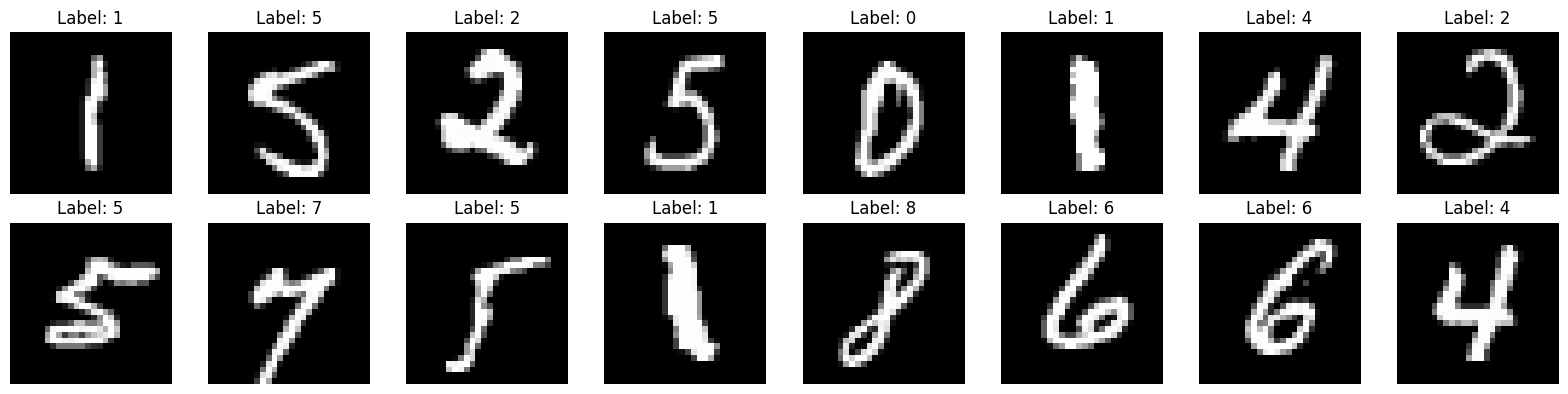

In [5]:
show_samples(train_loader, num_samples=16)

## CNN 모델 정의

3개의 Conv 블록(Conv → BatchNorm → ReLU → MaxPool) + FC 레이어 구조

In [ ]:
# CNN 모델 구조 정의
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.fc1     = nn.Linear(128 * 3 * 3, 128)
        self.fc2     = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.bn1(self.conv1(x))), 2)
        x = F.max_pool2d(F.relu(self.bn2(self.conv2(x))), 2)
        x = F.max_pool2d(F.relu(self.bn3(self.conv3(x))), 2)
        x = x.view(-1, 128 * 3 * 3)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)


model     = Net().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## 학습 / 평가 함수 정의

In [ ]:
# 학습 및 검증 루프 정의
def train(model, train_loader, optimizer, epoch):
    model.train()
    epoch_loss, correct, total = 0, 0, 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        pred = output.max(1, keepdim=True)[1]
        correct    += pred.eq(target.view_as(pred)).sum().item()
        total      += target.size(0)
        epoch_loss += loss.item()

        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

    train_losses.append(epoch_loss / len(train_loader))
    print(f'Training Accuracy: {100. * correct / total:.2f}%')


def evaluate(model, test_loader):
    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.max(1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss     /= len(test_loader.dataset)
    test_accuracy  = 100. * correct / len(test_loader.dataset)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    return test_loss, test_accuracy

## 학습 실행

In [8]:
for epoch in range(1, EPOCHS + 1):
    train(model, train_loader, optimizer, epoch)
    test_loss, test_accuracy = evaluate(model, test_loader)

    print('[{}] Test Loss: {:.4f}, Accuracy: {:.2f}%'.format(
          epoch, test_loss, test_accuracy))

    # 모델 저장 (에러율 기준 힙 관리)
    error_rate = 100 - test_accuracy
    model_info = {
        'epoch': epoch,
        'error_rate': error_rate,
        'accuracy': test_accuracy,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    heapq.heappush(model_heap, (error_rate, model_info))
    while len(model_heap) > MAX_MODELS:
        heapq.heappop(model_heap)

    print("\n현재 저장된 모델들의 에러율:")
    for err, info in sorted(model_heap):
        print(f"  Epoch {info['epoch']}: 에러율 {err:.2f}%, 정확도 {info['accuracy']:.2f}%")

    for i, (err, info) in enumerate(sorted(model_heap)):
        torch.save(info, f'models/mnist_cnn_top{i+1}_epoch_{info["epoch"]}.pt')

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.376220
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.232999
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.145312
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.187312
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.050520
Training Accuracy: 94.92%
[1] Test Loss: 0.0460, Accuracy: 98.43%

현재 저장된 모델들의 에러율:
  Epoch 1: 에러율 1.57%, 정확도 98.43%
Train Epoch: 2 [0/60000 (0%)]	Loss: 0.057381
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.099330
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.016588
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.108356
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.071908
Training Accuracy: 97.95%
[2] Test Loss: 0.0367, Accuracy: 98.76%

현재 저장된 모델들의 에러율:
  Epoch 2: 에러율 1.24%, 정확도 98.76%
  Epoch 1: 에러율 1.57%, 정확도 98.43%
Train Epoch: 3 [0/60000 (0%)]	Loss: 0.043056
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.027927
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.036157
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.086280
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.15030

## 러닝 커브

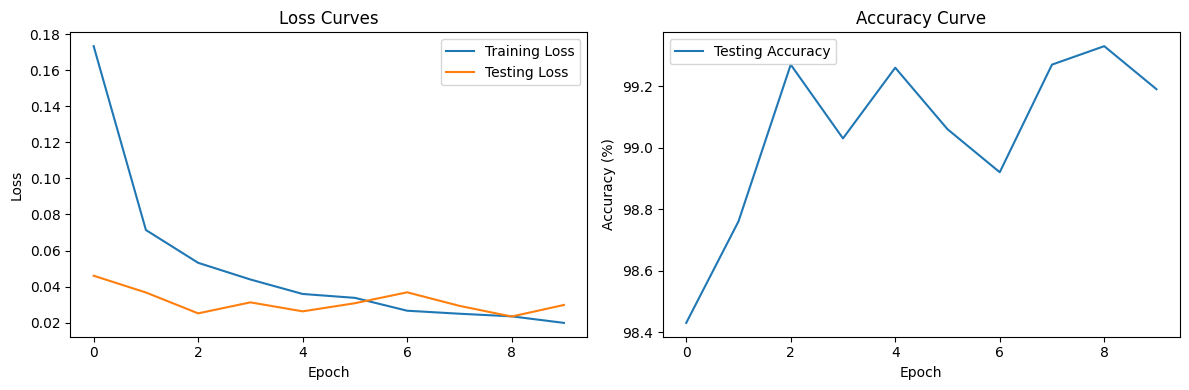

In [9]:
plot_learning_curves()

## Confusion Matrix

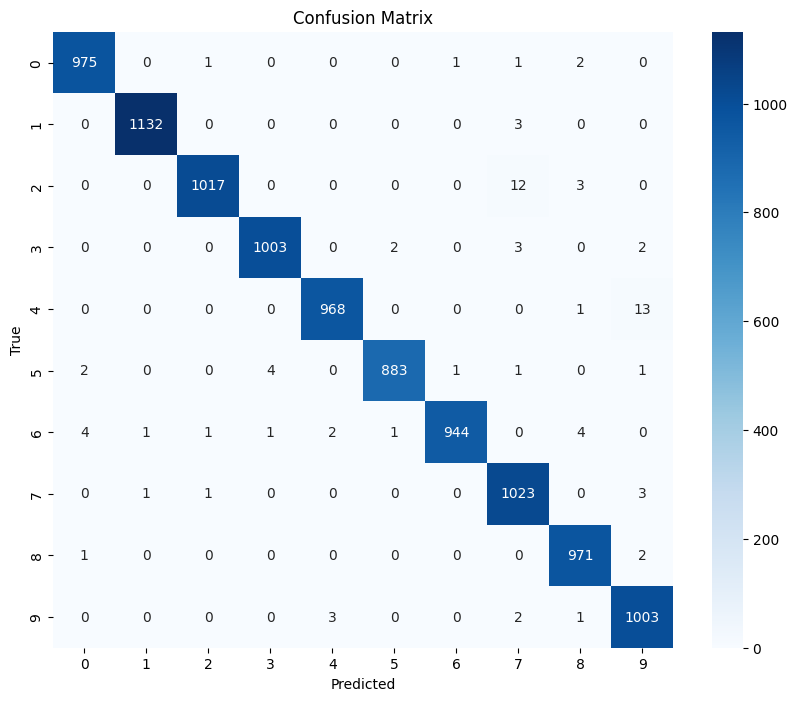

In [10]:
plot_confusion_matrix(model, test_loader)

## 최종 저장 모델 정보

In [ ]:
print("최종 저장된 모델 정보:")

# 에폭별 학습 실행
for i, (err, info) in enumerate(sorted(model_heap)):
    print(f"  Top {i+1} - Epoch {info['epoch']}: 에러율 {err:.2f}%, 정확도 {info['accuracy']:.2f}%")

최종 저장된 모델 정보:
  Top 1 - Epoch 6: 에러율 0.94%, 정확도 99.06%
  Top 2 - Epoch 4: 에러율 0.97%, 정확도 99.03%
  Top 3 - Epoch 7: 에러율 1.08%, 정확도 98.92%
  Top 4 - Epoch 2: 에러율 1.24%, 정확도 98.76%
  Top 5 - Epoch 1: 에러율 1.57%, 정확도 98.43%
